# Error Analysis and System Insights

This notebook works at the prediction-row level using `outputs/benchmark_predictions.csv`. It is analysis-only and does not call APIs or models.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either repo-root or notebooks/ execution."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "SMSSpamCollection").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find project root containing data/SMSSpamCollection and src/.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "SMSSpamCollection"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
print(f"Project root: {PROJECT_ROOT.relative_to(PROJECT_ROOT)} (resolved internally)")

Project root: . (resolved internally)


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

PREDICTIONS_PATH = OUTPUTS_DIR / "benchmark_predictions.csv"
HAVE_FILES = PREDICTIONS_PATH.exists()
if not HAVE_FILES:
    display(Markdown("""**Missing prediction artifact.** Run this from the repo root before using this notebook:

```bash
python -m src.benchmark --modes tfidf_lr,base_llm,basic_rag,advanced_base,advanced_lora,guarded_fallback --sample-size 30
```"""))
else:
    predictions = pd.read_csv(PREDICTIONS_PATH)
    print("Prediction artifact found.")

Prediction artifact found.


## Prediction Rows and Modes

The benchmark writes one row per `(mode, sms)` pair, enabling same-message comparisons across systems.

In [3]:
if HAVE_FILES:
    print(f"Rows: {len(predictions):,}")
    modes = predictions["mode"].drop_duplicates().tolist()
    print(f"Modes: {modes}")
    display(predictions.head())

Rows: 180
Modes: ['tfidf_lr', 'base_llm', 'basic_rag', 'advanced_base', 'advanced_lora', 'guarded_fallback']


,mode,sms_id,original_index,text,true_label,predicted_label,latency_seconds,raw_output,error_message,evidence_count,...,lora_verification,has_url,has_phone,has_currency,has_urgent_word,has_prize_word,has_call_instr,uppercase_ratio,exclamation_count,message_length
0,tfidf_lr,299,1598,URGENT! Your Mobile number has been awarded wi...,spam,spam,0.0003,spam,NaN,NaN,...,NaN,False,True,True,True,True,True,0.2283,1,143
1,tfidf_lr,358,4659,This message is from a great Doctor in India:-...,ham,ham,0.0002,ham,NaN,NaN,...,NaN,False,False,False,False,False,False,0.1750,0,106
2,tfidf_lr,765,3238,Ron say fri leh. N he said ding tai feng cant ...,ham,ham,0.0001,ham,NaN,NaN,...,NaN,False,False,False,False,False,False,0.0455,0,86
3,tfidf_lr,118,4700,Yes fine,ham,ham,0.0001,ham,NaN,NaN,...,NaN,False,False,False,False,False,False,0.1429,0,9
4,tfidf_lr,396,1247,"I do know what u mean, is the king of not hav...",ham,ham,0.0002,ham,NaN,NaN,...,NaN,False,False,False,True,False,False,0.0494,3,111


## Errors by Mode

Runtime errors are captured as `unknown` predictions with an error message. This benchmark run should have no model/runtime errors.

In [4]:
if HAVE_FILES:
    error_summary = (
        predictions.assign(has_error=predictions["error_message"].fillna("").astype(str).str.len() > 0)
        .groupby("mode")["has_error"]
        .agg(error_count="sum", rows="count")
        .reset_index()
    )
    display(error_summary)

,mode,error_count,rows
0,advanced_base,0,30
1,advanced_lora,0,30
2,base_llm,0,30
3,basic_rag,0,30
4,guarded_fallback,0,30
5,tfidf_lr,0,30


## False Positives and False Negatives

False negatives are especially important: they represent true spam that the system labeled as ham or unknown.

,mode,false_positive,false_negative
0,advanced_base,0,0
1,advanced_lora,0,4
2,base_llm,3,1
3,basic_rag,0,0
4,guarded_fallback,0,0
5,tfidf_lr,0,1


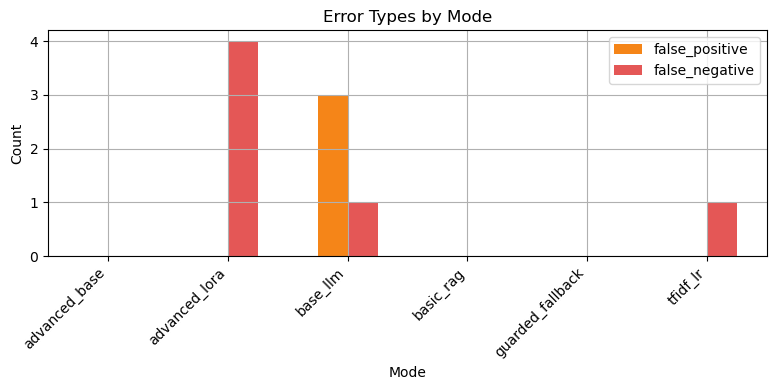

In [5]:
if HAVE_FILES:
    errors = predictions[predictions["true_label"] != predictions["predicted_label"]].copy()
    fp = predictions[(predictions["true_label"] == "ham") & (predictions["predicted_label"] == "spam")].copy()
    fn = predictions[(predictions["true_label"] == "spam") & (predictions["predicted_label"] != "spam")].copy()

    error_counts = (
        predictions.assign(
            false_positive=(predictions["true_label"] == "ham") & (predictions["predicted_label"] == "spam"),
            false_negative=(predictions["true_label"] == "spam") & (predictions["predicted_label"] != "spam"),
        )
        .groupby("mode")[["false_positive", "false_negative"]]
        .sum()
        .astype(int)
        .reset_index()
    )
    display(error_counts)

    ax = error_counts.plot(kind="bar", x="mode", y=["false_positive", "false_negative"], color=["#F58518", "#E45756"])
    ax.set_title("Error Types by Mode")
    ax.set_xlabel("Mode")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Advanced LoRA's main issue is false negatives: spam messages are being labeled as ham. The grounded RAG modes and guarded fallback avoid those misses in this sample.

## Advanced LoRA vs Guarded Fallback

Compare the two modes on the same `sms_id` and `original_index` to identify LoRA failures recovered by the fallback path.

In [6]:
if HAVE_FILES:
    lora = predictions[predictions["mode"] == "advanced_lora"].copy()
    guarded = predictions[predictions["mode"] == "guarded_fallback"].copy()
    compare_cols = ["sms_id", "original_index", "text", "true_label", "predicted_label"]
    comparison = lora[compare_cols].merge(
        guarded[["sms_id", "original_index", "predicted_label", "fallback_used", "initial_lora_prediction", "lora_verification"]],
        on=["sms_id", "original_index"],
        suffixes=("_lora", "_guarded"),
    )
    comparison["guarded_correct"] = comparison["predicted_label_guarded"] == comparison["true_label"]
    display(comparison.head(10))

,sms_id,original_index,text,true_label,predicted_label_lora,predicted_label_guarded,fallback_used,initial_lora_prediction,lora_verification,guarded_correct
0,299,1598,URGENT! Your Mobile number has been awarded wi...,spam,ham,spam,True,ham,unsupported,True
1,358,4659,This message is from a great Doctor in India:-...,ham,ham,ham,False,ham,supported,True
2,765,3238,Ron say fri leh. N he said ding tai feng cant ...,ham,ham,ham,False,ham,supported,True
3,118,4700,Yes fine,ham,ham,ham,False,ham,supported,True
4,396,1247,"I do know what u mean, is the king of not hav...",ham,ham,ham,False,ham,supported,True
5,557,2387,No message..no responce..what happend?,ham,ham,ham,False,ham,supported,True
6,994,4672,"Probably not, I'm almost out of gas and I get ...",ham,ham,ham,False,ham,supported,True
7,316,1489,Tell them no need to investigate about me anyw...,ham,ham,ham,False,ham,supported,True
8,427,3791,I love you !!! You know? Can you feel it? Does...,ham,ham,ham,False,ham,supported,True
9,382,3987,"Friendship is not a game to play, It is not a ...",ham,ham,ham,False,ham,supported,True


## LoRA Spam Misses Corrected by Guarded Fallback

These are the most important system-level wins: LoRA predicts ham for true spam, then the guarded fallback returns spam.

In [7]:
if HAVE_FILES:
    corrected = comparison[
        (comparison["true_label"] == "spam")
        & (comparison["predicted_label_lora"] == "ham")
        & (comparison["predicted_label_guarded"] == "spam")
    ].copy()
    print(f"Corrected LoRA spam misses: {len(corrected)}")
    display(corrected[[
        "sms_id",
        "original_index",
        "true_label",
        "predicted_label_lora",
        "predicted_label_guarded",
        "fallback_used",
        "lora_verification",
        "text",
    ]])

Corrected LoRA spam misses: 4


,sms_id,original_index,true_label,predicted_label_lora,predicted_label_guarded,fallback_used,lora_verification,text
0,299,1598,spam,ham,spam,True,unsupported,URGENT! Your Mobile number has been awarded wi...
15,180,2669,spam,ham,spam,True,unsupported,Wanna get laid 2nite? Want real Dogging locati...
24,970,1430,spam,ham,spam,True,unsupported,For sale - arsenal dartboard. Good condition b...
27,1009,1574,spam,ham,spam,True,unsupported,SMS AUCTION - A BRAND NEW Nokia 7250 is up 4 a...


Evidence-aware prompting alone did not fix the LoRA ham bias in this benchmark. The verifier plus base-agent fallback is what recovered the missed spam cases.

## Guarded Fallback Usage

Inspect rows where fallback was used, then check whether final predictions were correct.

In [8]:
if HAVE_FILES:
    guarded_rows = predictions[predictions["mode"] == "guarded_fallback"].copy()
    guarded_rows["fallback_used"] = guarded_rows["fallback_used"].fillna(False).astype(bool)
    fallback_rows = guarded_rows[guarded_rows["fallback_used"]].copy()
    fallback_rows["correct"] = fallback_rows["true_label"] == fallback_rows["predicted_label"]

    print(f"Fallback-used rows: {len(fallback_rows)}")
    if len(fallback_rows):
        display(fallback_rows["true_label"].value_counts().rename_axis("true_label").reset_index(name="count"))
        display(fallback_rows["correct"].value_counts().rename_axis("correct").reset_index(name="count"))
        display(fallback_rows[["sms_id", "original_index", "true_label", "predicted_label", "initial_lora_prediction", "lora_verification", "correct", "text"]])
    else:
        display(Markdown("No fallback rows were used in this benchmark output."))

Fallback-used rows: 5


/var/folders/yr/sc_cyb5j1_gcjmw2bh0_8hlc0000gn/T/ipykernel_82588/1481875141.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  guarded_rows["fallback_used"] = guarded_rows["fallback_used"].fillna(False).astype(bool)


,true_label,count
0,spam,4
1,ham,1


,correct,count
0,True,5


,sms_id,original_index,true_label,predicted_label,initial_lora_prediction,lora_verification,correct,text
150,299,1598,spam,spam,ham,unsupported,True,URGENT! Your Mobile number has been awarded wi...
165,180,2669,spam,spam,ham,unsupported,True,Wanna get laid 2nite? Want real Dogging locati...
173,472,4713,ham,ham,ham,unsupported,True,Thats cool princess! I will cover your face in...
174,970,1430,spam,spam,ham,unsupported,True,For sale - arsenal dartboard. Good condition b...
177,1009,1574,spam,spam,ham,unsupported,True,SMS AUCTION - A BRAND NEW Nokia 7250 is up 4 a...


Fallback usage gives a direct measure of how often the verifier distrusted the LoRA path. In this run, fallback rows are where the reliability gain appears.

## Risk Features and Error Patterns

Use logged risk features to summarize what kinds of messages were misclassified.

In [9]:
if HAVE_FILES:
    risk_cols = [
        "has_url",
        "has_phone",
        "has_currency",
        "has_urgent_word",
        "has_prize_word",
        "has_call_instr",
        "uppercase_ratio",
        "exclamation_count",
        "message_length",
    ]
    error_risk = errors.groupby("mode")[risk_cols].mean().round(4)
    if len(error_risk):
        display(error_risk)
    else:
        display(Markdown("No misclassified rows were found."))

    important_flags = ["has_prize_word", "has_currency", "has_urgent_word", "has_call_instr"]
    if len(errors):
        flag_summary = errors.groupby("mode")[important_flags].sum().astype(int).reset_index()
        display(flag_summary)
    else:
        display(Markdown("No error flag summary to display."))

,has_url,has_phone,has_currency,has_urgent_word,has_prize_word,has_call_instr,uppercase_ratio,exclamation_count,message_length
mode,,,,,,,,,
advanced_lora,0.0,0.75,0.5,0.75,0.5,0.75,0.1996,1.5,131.25
base_llm,0.0,0.00,0.0,0.00,0.0,0.00,0.0822,0.5,100.25
tfidf_lr,0.0,0.00,0.0,0.00,0.0,0.00,0.0351,1.0,71.00


,mode,has_prize_word,has_currency,has_urgent_word,has_call_instr
0,advanced_lora,2,2,3,3
1,base_llm,0,0,0,0
2,tfidf_lr,0,0,0,0


Misclassified spam should be inspected for prize, currency, urgency, and call/reply cues. In this benchmark, those cues help explain why the LoRA misses are concerning and why fallback correction matters.

## System Insights

- LoRA is locally integrated but biased toward ham on this sample.
- Evidence-aware prompting alone did not fix LoRA.
- Verifier plus fallback provides the actual reliability improvement.
- RAG grounding improves over the base LLM.
- The classical TF-IDF baseline remains competitive and fast, making it a strong benchmark anchor.